# MINTERPY/n-dimensional fitting for PA sn1CO2 using PCO sn2CO2 fragmentation data as template

In [5]:
# basic python packages
import numpy as np
import pandas as pd

# specific python packages
import minterpy as mp
import cvxpy as cp
# added by Damar for handling equations
import sympy as sp

# visualisation tools
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.widgets  import RectangleSelector
from minterpy.core.utils import get_exponent_matrix
import matplotlib.patches as patches

# others
import minterpy_functions as mf
import pickle

## Import of required data

### Import and conversion of PA sn1 FA(!) fragmentation data

PA sn1 FA data are generated from fitting an adjusted template from PA sn2FA + CO2

In [6]:
# Read PCsym data
data  = pd.read_csv(r"./frag_data/220614_PA_sym-sn1-sn2_FA.csv")

# get sn2 norm_intensity and _var averaged
cols = ['FA_C_x', 'FA_DB_x', 'FA_iso_x', 'sn_x', 'CE']
intensity = data[(data['sn_x'] == 1) & (data['sn_y'] == 0)].groupby(by=cols)['norm_Intensity']
intensity_mean = intensity.mean()

intensity_var = data[(data['sn_x'] == 1) & (data['sn_y'] == 0)].groupby(by=cols)['norm_Intensity_var']
intensity_var_mean = intensity_var.mean()

# df combining the results
df = pd.concat([intensity_mean, intensity_var_mean], axis=1).reset_index()

# renaming of columns
df.columns = ['FA_C', 'FA_DB', 'FA_iso', 'sn_x', 'CE', 'norm_Intensity', 'norm_Intensity_var']

# add type col
df['Type'] = 1

# format for Minterpy
sample_points = df[['CE', 'FA_C', 'FA_DB', 'FA_iso', 'Type']].to_numpy()
function_vals = df['norm_Intensity'].to_numpy()
# weight_vals = df['norm_Intensity_var'].to_numpy()

print(f"No. of data points in SN1 = {len(function_vals)}")

No. of data points in SN1 = 305


### Visualizing dataset

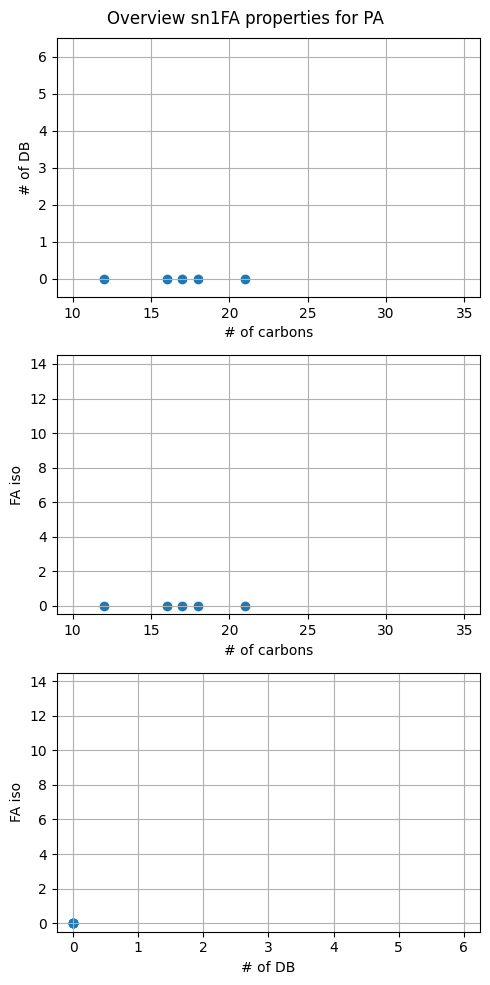

In [7]:
## get dataframe with needed properties
overview_df = df[['FA_C', 'FA_DB', 'FA_iso']].drop_duplicates()

fig, ax = plt.subplots(3,1, figsize=(5,10))

fig.suptitle('Overview sn1FA properties for PA')

# plot number of carbons vs number of DB
ax = plt.subplot(3,1,1)
plt.scatter(overview_df.FA_C, overview_df.FA_DB)
ax.set_xlim(9,36)
ax.set_ylim(-0.5,6.5)
ax.set_xlabel('# of carbons')
ax.set_ylabel('# of DB')
ax.grid(which='both')

# plot number of carbons vs DB position
ax = plt.subplot(3,1,2)
plt.scatter(overview_df.FA_C, overview_df.FA_iso)
ax.set_xlim(9,36)
ax.set_ylim(-0.5,14.5)
ax.set_xlabel('# of carbons')
ax.set_ylabel('FA iso')
ax.grid(which='both')

# plot number of DB vs DB position
ax = plt.subplot(3,1,3)
plt.scatter(overview_df.FA_DB, overview_df.FA_iso)
ax.set_xlim(-0.25,6.25)
ax.set_ylim(-0.5,14.5)
ax.set_xlabel('# of DB')
ax.set_ylabel('FA iso')
ax.grid(which='both')

plt.tight_layout()
plt.show()

Note: PA sn1 has only saturated items. For this reason, we apply the template model.

## Import of template PA sn2FA+CO2 data

In [8]:
## import PAsn2 CO2NL as template

## type 1 == FA + CO2NL, type 0 == FA

template_df = pickle.load(open('./helper/FA_CO2NL_PAsn2_template.pkl', 'rb'))

cols = ['CE', 'FA_C', 'FA_DB', 'FA_iso', 'Type']

sample_points_template = template_df[cols].to_numpy()
function_vals_template = template_df['norm_Intensity'].to_numpy()

## MINTERPY/n-dimensional fitting of scaled PA sn2FA + CO2 template

PA sn1FA dataset is used for training the polynomial model. For this, the PA sn2 FA + CO2 dataset is scaled to match PA sn1 and used for fitting with Minterpy.

In [9]:
# Reorganize data for fitting
size_data = function_vals.shape[0] # class of interest
size_data_template = function_vals_template.shape[0] # template data

size_train_data_wtemplate = size_data + size_data_template # total size

train_sample_points = np.vstack([sample_points, sample_points_template])
train_function_vals = np.zeros(size_train_data_wtemplate)

# populate train_function_vals with values
train_function_vals[:size_data] = function_vals
# scaling of PCO dataset
scaled_template_function_vals = function_vals_template/np.max(function_vals_template) * np.max(function_vals)

train_function_vals[size_data:] = scaled_template_function_vals

In [10]:
sparse_poly_model = mf.lasso_fit_data(train_sample_points,
                                        train_function_vals,
                                        poly_degree_along=[8,2,2,2,1], 
                                        weighted=True)

c:\Users\schuhmann\AppData\Local\Programs\Python\Python312\Lib\site-packages\minterpy\schemes\barycentric\operators.py:47: UserWarning: building a full transformation matrix from a barycentric transformation. this is inefficient.
  warn(


Optimizer result : 179.9639461723532


### extract PA sn2CO2 fragment data

In [11]:
## get template intensity data from fitting for PA

lower_bounds = np.round(np.amin(train_sample_points, axis=0))
upper_bounds = np.round(np.amax(train_sample_points, axis=0))+1.0

## import list of CO2NL species
CO2NLspecies = pickle.load(open('./helper/CO2NL_species.pkl', 'rb'))

In [12]:
# lower_bounds[0] = 10
# upper_bounds[0] = 60

data_l = []
typel = [1,0]

for i in CO2NLspecies:
    for j in typel:
        num_points_in_grid = int(upper_bounds[0] - lower_bounds[0])+1

        xvals = np.linspace(lower_bounds[0], upper_bounds[0], num_points_in_grid)

        eval_points = np.zeros((num_points_in_grid, 5))
        eval_points[:,0] = xvals ## NCE
        eval_points[:,1] = np.full((1,num_points_in_grid), i[0]) ## FA_C
        eval_points[:,2] = i[1]
        eval_points[:,3] = i[2]
        eval_points[:,4] = j

        intensity = pd.DataFrame(pow(2, mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)))
        data = pd.DataFrame(eval_points)
        data_l.append(pd.concat([data, intensity], axis=1))

pasn2_FA_template_df = pd.concat(data_l)

In [13]:
## reshape data and calculation of projected CO2NL intensities
pasn2_FA_template_df.columns = ['CE', 'FA_C', 'FA_DB', 'FA_iso', 'Type', 'norm_Intensity']
remove_col = ['norm_Intensity', 'Type']
info = pasn2_FA_template_df[pasn2_FA_template_df['Type']==1].drop(remove_col, axis=1)
## type == 1 is FA+CO2NL
## type == 0 is FA only
## CO2 losses are projected from fitting type == 0
intensity = pasn2_FA_template_df[pasn2_FA_template_df['Type'] == 1]['norm_Intensity'] - pasn2_FA_template_df[pasn2_FA_template_df['Type'] == 0]['norm_Intensity']

### !!!! ####
## the constructed data can now be fitted with 4 variable
CO2intensity_df = pd.concat([info, intensity], axis=1)
# CO2intensity_df = CO2intensity_df[(CO2intensity_df['norm_Intensity'] > 0) & (CO2intensity_df['CE'] < 50)]
## dataframe with projected intensities
CO2intensity_df = CO2intensity_df[CO2intensity_df['norm_Intensity'] > 0]

In [14]:
cols = ['CE', 'FA_C', 'FA_DB', 'FA_iso']

sample_points_2 = CO2intensity_df[cols].to_numpy()
function_vals_2 = CO2intensity_df['norm_Intensity'].to_numpy() # This is already in log scale

sparse_poly_model_2 = mf.lasso_fit_data(sample_points_2,
                                       function_vals_2, 
                                       poly_degree_along=[8,2,2,1],
                                       weighted=True)

c:\Users\schuhmann\AppData\Local\Programs\Python\Python312\Lib\site-packages\minterpy\schemes\barycentric\operators.py:47: UserWarning: building a full transformation matrix from a barycentric transformation. this is inefficient.
  warn(


Optimizer result : 42.87664778702393


L_inf error of fitting SYM dataset = 0.36651671360109517


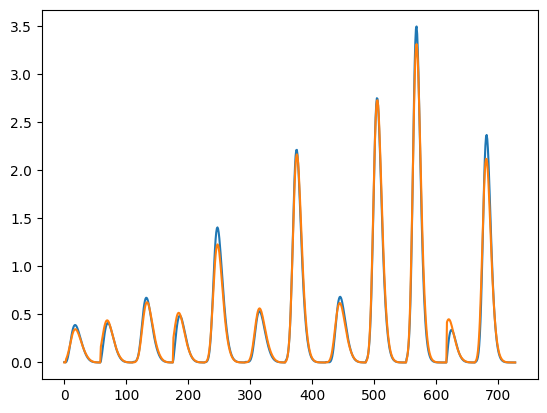

In [15]:
lower_bounds = np.round(np.amin(sample_points_2, axis=0))
upper_bounds = np.round(np.amax(sample_points_2, axis=0))+1.0

eval_vals = mf.poly_evaluate_at(sparse_poly_model_2, sample_points_2, lower_bounds, upper_bounds)

Linf_error = np.max(np.abs(pow(2,eval_vals) - function_vals_2))
print(f"L_inf error of fitting SYM dataset = {Linf_error}")
plt.plot(function_vals_2)
plt.plot(pow(2,eval_vals))
# plt.xlim(900,1100)
plt.show()

## Visualization of fitting data/results

### Fragment intensity contour plot for FA 18:x (9Z)

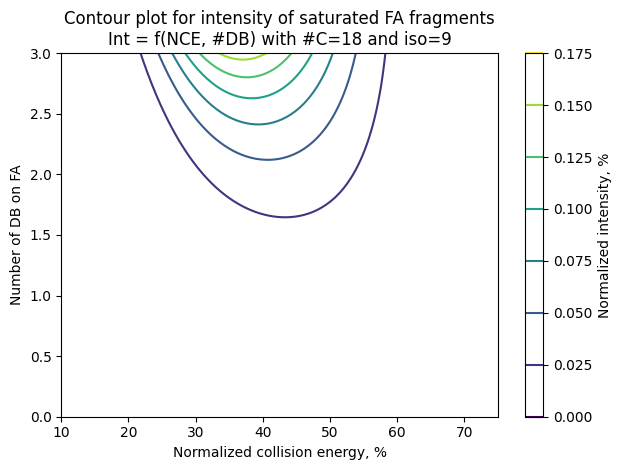

In [16]:
xlo = lower_bounds[0]
xhi = upper_bounds[0]
ylo = 0 #lower_bounds[2]
yhi = 3 #upper_bounds[2]

xvals = np.linspace(xlo, xhi, 100)
yvals = np.linspace(ylo, yhi, 100)

# yvals

X,Y = np.meshgrid(xvals, yvals)
coords_x = X.reshape(-1)
coords_y = Y.reshape(-1)

fa_c = 18
fa_iso = 9

num_points_in_grid = len(coords_y)
eval_points = np.zeros((num_points_in_grid, 4))
eval_points[:,0] = coords_x
eval_points[:,1] = fa_c
eval_points[:,2] = coords_y
eval_points[:,3] = fa_iso

eval_vals = mf.poly_evaluate_at(sparse_poly_model_2, eval_points, lower_bounds, upper_bounds)

plt.title("Contour plot for intensity of saturated FA fragments\nInt = f(NCE, #DB) with #C=18 and iso=9")
plt.xlabel("Normalized collision energy, %")
plt.ylabel("Number of DB on FA")
plt.contour(X,Y, pow(2,eval_vals.reshape((100,100))))
plt.colorbar().set_label('Normalized intensity, %')

plt.tight_layout()
plt.show()

### Fragment intensity contour plot for FA 20:x (5Z)

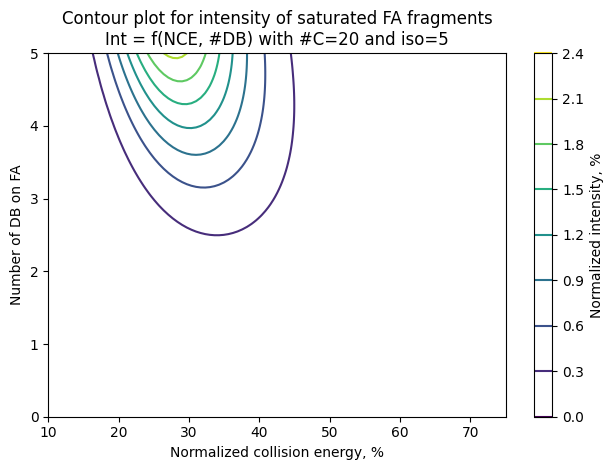

In [17]:
xlo = lower_bounds[0]
xhi = upper_bounds[0]
ylo = 0 #lower_bounds[2]
yhi = 5 #upper_bounds[2]

xvals = np.linspace(xlo, xhi, 100)
yvals = np.linspace(ylo, yhi, 100)

# yvals

X,Y = np.meshgrid(xvals, yvals)
coords_x = X.reshape(-1)
coords_y = Y.reshape(-1)

fa_c = 20
fa_iso = 5

num_points_in_grid = len(coords_y)
eval_points = np.zeros((num_points_in_grid, 4))
eval_points[:,0] = coords_x
eval_points[:,1] = fa_c
eval_points[:,2] = coords_y
eval_points[:,3] = fa_iso

eval_vals = mf.poly_evaluate_at(sparse_poly_model_2, eval_points, lower_bounds, upper_bounds)

plt.title("Contour plot for intensity of saturated FA fragments\nInt = f(NCE, #DB) with #C=20 and iso=5")
plt.xlabel("Normalized collision energy, %")
plt.ylabel("Number of DB on FA")
plt.contour(X,Y, pow(2,eval_vals.reshape((100,100))))
plt.colorbar().set_label('Normalized intensity, %')

plt.tight_layout()
plt.show()

#### Comparison for main FA with 0-6 DBs

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


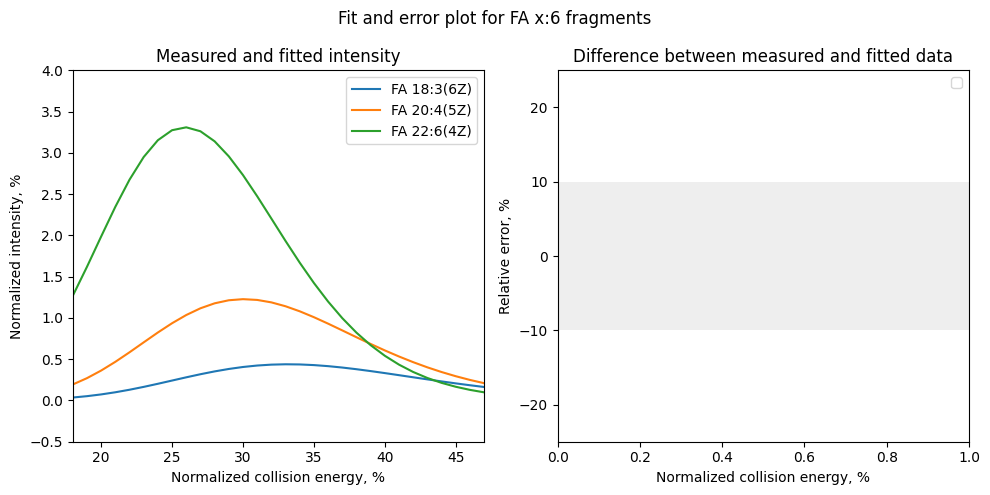

In [18]:
# color definition for plots
colors = [('tab:blue', '#1f77b4'), ('tab:orange', '#ff7f0e'), ('tab:green', '#2ca02c'), ('tab:red', '#d62728'), ('tab:purple', '#9467bd'), ('tab:brown', '#8c564b'), ('tab:pink', '#e377c2'), ('tab:gray', '#7f7f7f'), ('tab:olive', '#bcbd22'), ('tab:cyan', '#17becf')]

nce = [10,70] # range of nce
FA_oi = [[18, 3, 6], [20, 4, 5], [22, 6, 4]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))

fig.suptitle("Fit and error plot for FA x:6 fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model_2, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])
    ax[0].set_xlim(18,47)
    ax[0].set_ylim(-0.5,4)

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [19]:
# Transformation of NewtonPolynomials to Canonical Form
model_can = mp.get_transformation(sparse_poly_model_2, mp.CanonicalPolynomial)()

trimmed_coeffs = model_can.coeffs.copy()

# conditional coefficient modification, if needed
# trimmed_coeffs[np.where((trimmed_coeffs<1e0) & (trimmed_coeffs>-1e0))] = 0.0
# trimmed_coeffs = np.around(trimmed_coeffs, 2)

model_can.coeffs = trimmed_coeffs
model_eqn = mf.mp_to_sympy(model_can)

# conversion to equation
model_eqn

Poly(1.28729048542036e-12*x_0**8 + 2.20268248085631e-13*x_0**7*x_1**2*x_2**2*x_3 - 1.06581410364015e-12*x_0**7*x_1**2*x_2**2 + 1.35003119794422e-13*x_0**7*x_1**2*x_2*x_3 - 3.41060513164855e-13*x_0**7*x_1**2*x_2 + 7.31859017832919e-13*x_0**7*x_1**2*x_3 - 1.98424061124669e-12*x_0**7*x_1**2 + 3.55271367880035e-14*x_0**7*x_1*x_2**2*x_3 - 1.42108547152013e-14*x_0**7*x_1*x_2**2 + 3.55271367880044e-14*x_0**7*x_1*x_2*x_3 + 5.68434188608087e-14*x_0**7*x_1*x_2 + 1.63424829224823e-13*x_0**7*x_1*x_3 - 3.05627065239451e-13*x_0**7*x_1 + 5.75539615965691e-13*x_0**7*x_2**2*x_3 - 1.8386853777505e-12*x_0**7*x_2**2 + 5.47117906535276e-13*x_0**7*x_2*x_3 - 8.31335000839317e-13*x_0**7*x_2 + 2.72848410531875e-12*x_0**7*x_3 - 5.40155592747041e-12*x_0**7 + 1.80744308408973e-13*x_0**6*x_1**2*x_2**2*x_3 - 4.55191440096311e-13*x_0**6*x_1**2*x_2**2 + 9.68114477473112e-14*x_0**6*x_1**2*x_2*x_3 - 1.48325796089916e-13*x_0**6*x_1**2*x_2 + 1.07913677993559e-13*x_0**6*x_1**2*x_3 - 6.80788758700123e-13*x_0**6*x_1**2 - 1.

## Save the polynomial function as pickle

In [20]:
# write polynomial coefficients and exponents to dictionary for export
poly_info = {'coeffs': sparse_poly_model_2.coeffs, 'exponents': sparse_poly_model_2.multi_index.exponents, 'lower_bounds': lower_bounds, 'upper_bounds': upper_bounds}

# Storing the polynomial object in a file
pickle.dump(poly_info, open(r'./polynomials/240925_PA_sn1CO2_poly.pkl', 'ab'))

In [21]:
poly_info

{'coeffs': array([-2.49581900e+01, -1.11939261e+01, -1.16358581e+01, -1.70546420e+00,
        -6.05084776e+00, -6.28403996e-11,  2.50111043e-12, -1.46940238e-11,
         1.30465519e-12,  8.95009394e-01,  7.23136606e-01,  1.84297022e-12,
         1.66700598e-01,  2.44426701e-12, -7.52287121e-13,  8.59756710e-13,
        -4.97379915e-13,  1.12008754e+00, -1.91722194e-11, -8.86402063e-12,
        -3.32960326e-11, -7.85504994e-12, -1.79758430e-11, -1.66977543e-12,
        -4.47641924e-12, -4.62728486e+00, -3.83591557e+00, -6.42952358e-12,
        -1.74633641e-11, -4.57678340e-12, -8.62243610e-12, -8.06466005e-13,
        -1.87583282e-12,  1.94257912e-02,  1.58228985e-12,  8.84181617e-13,
         2.04014583e-12,  7.88258347e-13,  5.63549207e-13,  2.23820962e-13,
         2.13162821e-14, -4.66293670e-12, -2.52975418e-12, -1.72306613e-12,
        -4.32276437e-12, -1.32560629e-12, -1.93400851e-12, -2.45137244e-13,
        -4.76063633e-13, -1.22182248e+00, -1.57092117e-11, -4.04298817e-12,
  